In [1]:
# This script uses class definition to store, access and compute GP Observables in an organized manner

import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import datetime
import time

if not torch.cuda.is_available():
    print('Cuda not available')

### Cost Function Definition

In [2]:
# Multi-Trajectory Cost Function Definition

def get_cost_AC(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function using a single differentiable GP forward pass per observable,
    merging the training and prediction steps by passing Z[:, i] directly to the forward method.
    
    Args:
        Z: Tensor of shape (r**n, p), decision variable (requires grad).
        X: Tensor of shape (n, nT*N), dataset of N steps per trajectory.
        Xplus: Tensor of shape (n, nT*N), time-shifted dataset.
        Xtrain: Tensor of shape (n, r**n), gridpoints for training.
        manager: GPObservablesManager.
        nT: Number of trajectories.
        lambda1: Weighting for NLPD.
        lambda2: Weighting for linearity enforcement.
        lambda3: Weighting for prediction error minimization.
    """
    N = X.shape[1] // nT    # Number of time steps per trajectory
    p = Z.shape[1]          # Number of observables
    l = Z.shape[0] // nT    # Decision horizon
    n = X.shape[0]          # State dimension

    # For each observable, call forward once on the full dataset X (and Xplus)
    M = torch.empty((p, N * nT), device=X.device)
    cov_all = [None] * p  # store full covariance matrices for X
    Mplus = torch.empty((p, N * nT), device=X.device)
    # cov_all_plus = [None] * p  # store full covariance matrices for Xplus

    for i in range(p):
        mean_i, cov_i = manager.observables[i].forward(X, Z[:, i])
        M[i, :] = torch.transpose(mean_i, 0, -1)
        cov_all[i] = cov_i

        mean_plus_i, _ = manager.observables[i].forward(Xplus, Z[:, i])
        Mplus[i, :] = torch.transpose(mean_plus_i, 0, -1)

    # Compute the pseudo-inverse lifting operator and the corresponding matrices Cz and Az.
    M_pinv = torch.linalg.pinv(M)
    Cz = X @ M_pinv
    Az = Mplus @ M_pinv

    # Cost Term 1: Negative Log Predictive Density (NLPD)
    NormNLPD = 0.0
    if not math.isclose(lambda1, 0):
        for j in range(nT):
            TrajNLPD = 0.0
            # Define the number of time steps for NLPD computation:
            num_steps = N - 2 - l
            vz_k = torch.empty((p, num_steps), device=X.device)
            for i in range(p):
                # For trajectory j, determine the indices for the NLPD slice.
                start = j * N + l + 1
                end = (j + 1) * N - 1  # end is exclusive
                # Extract the covariance for the slice from the precomputed full covariance.
                cov_sub = cov_all[i][start:end, start:end]
                # Get the diagonal elements (predictive variances) and clamp them.
                vz_k[i, :] = torch.clamp(torch.diag(cov_sub), min=1e-3)
            for k in range(num_steps):
                vx_next = torch.abs(torch.diag(Cz @ Az @ torch.diag(vz_k[:, k]) @ Az.T @ Cz.T).view(n, 1))
                error_term = ((X[:, j * N + l + 1 + k + 1] - Cz @ Az @ M[:, j * N + l + 1 + k]) ** 2) / vx_next
                log_term = torch.log(vx_next)
                TrajNLPD += torch.sum(error_term + log_term)
            NormNLPD += TrajNLPD

    # Cost Term 2: Linearity Enforcement
    NormLEP = 0.0
    if not math.isclose(lambda2, 0):
        for j in range(nT):
            TrajLEP = 0.0
            for k in range(l - 1):
                lin_error = torch.transpose(Z[j * l + k + 1, :], 0, -1) - Az @ torch.transpose(Z[j * l + k, :], 0, -1)
                TrajLEP += torch.norm(lin_error)
            NormLEP += TrajLEP

    # Cost Term 3: Prediction Error Minimization
    NormPEM = 0.0
    if not math.isclose(lambda3, 0):
        for j in range(nT):
            TrajPEM = 0.0
            for k in range(N - 1):
                pred_error = X[:, j * N + (k + 1)] - Cz @ (torch.linalg.matrix_power(Az, k + 1)) @ M[:, j * N]
                TrajPEM += torch.norm(pred_error)
            NormPEM += TrajPEM

    cost = (lambda1 * NormNLPD / ((N - l) * nT)) + (lambda2 * NormLEP / (l * nT)) + (lambda3 * NormPEM / (N * nT))
    return cost


def get_cost_ACnew(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function using a single differentiable GP forward pass per observable,
    merging the training and prediction steps by passing Z[:, i] directly to the forward method.
    
    Args:
        Z: Tensor of shape (nT*l, p), decision variable (requires grad).
        X: Tensor of shape (n, nT*N), dataset of N steps per trajectory.
        Xplus: Tensor of shape (n, nT*N), time-shifted dataset.
        Xtrain: Tensor of shape (n, r**n), gridpoints for training.
        manager: GPObservablesManager.
        nT: Number of trajectories.
        lambda1: Weighting for NLPD.
        lambda2: Weighting for linearity enforcement.
        lambda3: Weighting for prediction error minimization.
    """
    N = X.shape[1] // nT    # Number of time steps per trajectory
    p = Z.shape[1]          # Number of observables
    l = Z.shape[0] // nT    # Decision horizon
    n = X.shape[0]          # State dimension

    # For each observable, call forward once on the full dataset X (and Xplus)
    M = torch.empty((p, N * nT), device=X.device)
    Mplus = torch.empty((p, N * nT), device=X.device)
    diag_all = torch.empty((p, N * nT), device=X.device)
    diag_all_plus = torch.empty((p, N * nT), device=X.device)
    # cov_all_plus = [None] * p  # store full covariance matrices for Xplus

    for i in range(p):
        mean_i, cov_i = manager.observables[i].forward(X, Z[:, i])
        M[i, :] = torch.transpose(mean_i, 0, -1)
        diag_all[i] = torch.clamp(torch.diagonal(cov_i), min=1e-3)

        mean_plus_i, cov_plus_i = manager.observables[i].forward(Xplus, Z[:, i])
        Mplus[i, :] = torch.transpose(mean_plus_i, 0, -1)
        diag_all_plus[i] = torch.clamp(torch.diagonal(cov_plus_i), min=1e-3)

    # Compute the pseudo-inverse lifting operator and the corresponding matrices Cz and Az.
    M_pinv = torch.linalg.pinv(M)
    Cz = X @ M_pinv
    Az = Mplus @ M_pinv

    # Cost Term 1: Negative Log Predictive Density (NLPD)
    NormNLPD = 0.0
    if not math.isclose(lambda1, 0):
        # Define the number of time steps for NLPD computation:
        num_steps = N - 2 - l
        vz_k = torch.empty((p, num_steps), device=X.device)
        
        for j in range(nT):
            TrajNLPD = 0.0
            # For trajectory j, determine the indices for the NLPD slice.
            start = j * N + l + 1
            end = (j + 1) * N - 1  # end is exclusive
            vz_k = diag_all[:, start:end]

            # for i in range(p):
            #     # Extract the covariance for the slice from the precomputed full covariance.
            #     cov_sub = cov_all[i][start:end, start:end]
            #     # Get the diagonal elements (predictive variances) and clamp them.
            #     vz_k[i, :] = torch.clamp(torch.diag(cov_sub), min=1e-3)
            
            for k in range(num_steps):
                Dvk = torch.diag(vz_k[:, k])
                vx_next = torch.abs(Cz @ Az @ Dvk @ Az.T @ Cz.T)
                # try:
                #     L = torch.linalg.cholesky(vx_next)
                #     vx_next_inv = torch.cholesky_inverse(L)
                # except RuntimeError:
                #     vx_next_inv = torch.inverse(vx_next)
                L = torch.linalg.cholesky(vx_next)
                vx_next_inv = torch.cholesky_inverse(L)

                err_next = (X[:, j * N + l + 1 + k + 1] - Cz @ Az @ M[:, j * N + l + 1 + k])
                error_term = err_next.T @ vx_next_inv @ err_next
                
                log_term = torch.logdet(vx_next)

                TrajNLPD += error_term + log_term

            NormNLPD += TrajNLPD

    # # Cost Term 2: Linearity Enforcement
    # NormLEP = 0.0
    # if not math.isclose(lambda2, 0):
    #     for j in range(nT):
    #         TrajLEP = 0.0
    #         for k in range(l - 1):
    #             lin_error = torch.transpose(Z[j * l + k + 1, :], 0, -1) - Az @ torch.transpose(Z[j * l + k, :], 0, -1)
    #             TrajLEP += torch.norm(lin_error)
    #         NormLEP += TrajLEP

    # Cost Term 2: Lifting Accuracy
    NormLift = 0.0
    if not lambda2 == 0:
        num_steps = N
        vz_k = torch.empty((p, num_steps), device=X.device)
        vz_kp = torch.empty((p, num_steps), device=X.device)

        for j in range(nT):
            TrajLift = 0.0
            vz_k = diag_all[:, j*N : (j+1)*N]
            vz_kp = diag_all_plus[:, j*N : (j+1)*N]
            
            for k in range(num_steps):
                Dvkp_k = Az @ torch.diag(vz_k[:, k]) @ Az.T # form covar diag-matrix at k
                Dvkp_kp = torch.diag(vz_kp[:, k])
                
                sigma = 0.5 * (Dvkp_k + Dvkp_kp)
                L = torch.linalg.cholesky(sigma)
                sigma_inv = torch.cholesky_inverse(L)
                err = Mplus[:, j*N + k] - (Az @ M[:, j*N + k])
                log_term = torch.logdet(sigma) - 0.5 * ( torch.logdet(Dvkp_k) + torch.logdet(Dvkp_kp) )
                TrajLift += ((err.T @ sigma_inv @ err)/8) + 0.5 * log_term
            
            NormLift += TrajLift

    # Cost Term 3: Reconstruction
    NormRecon = 0.0
    if not lambda3 == 0:
        num_steps = N
        vz_k = torch.empty((p, num_steps), device=X.device)

        for j in range(nT):
            TrajRecon = 0.0
            vz_k = diag_all[:, j*N : (j+1)*N]

            for k in range(num_steps):
                Dvk = torch.diag(vz_k[:,k])
                vx_k = Cz @ Dvk @ Cz.T

                L = torch.linalg.cholesky(vx_k)
                vx_k_inv = torch.cholesky_inverse(L)

                err_k = X[:, j*N + k] - Cz @ M[:, j*N + k]
                err_term = err_k.T @ vx_k_inv @ err_k.T

                log_term = torch.logdet(vx_k)

                TrajRecon += err_term + log_term
            
            NormRecon += TrajRecon

    cost = (lambda1 * NormNLPD / ((N - l) * nT)) + (lambda2 * NormLift / (N * nT)) + (lambda3 * NormRecon / (N * nT))
    return cost


def get_cost_ACnew2(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function using a single differentiable GP forward pass per observable,
    merging the training and prediction steps by passing Z[:, i] directly to the forward method.
    
    Args:
        Z: Tensor of shape (nT*l, p), decision variable (requires grad).
        X: Tensor of shape (n, nT*N), dataset of N steps per trajectory.
        Xplus: Tensor of shape (n, nT*N), time-shifted dataset.
        Xtrain: Tensor of shape (n, r**n), gridpoints for training.
        manager: GPObservablesManager.
        nT: Number of trajectories.
        lambda1: Weighting for multi-variate NLPD
        lambda2: Weighting for Lifting Accuracy (Bhattacharyya Distance)
        lambda3: Weighting for Reconstruction
    """
    N = X.shape[1] // nT    # Number of time steps per trajectory
    p = Z.shape[1]          # Number of observables
    l = Z.shape[0] // nT    # Decision horizon
    n = X.shape[0]          # State dimension

    # For each observable, call forward once on the full dataset X (and Xplus)
    M = torch.empty((p, N * nT), device=X.device)
    Mplus = torch.empty((p, N * nT), device=X.device)
    diag_all = torch.empty((p, N * nT), device=X.device)
    diag_all_plus = torch.empty((p, N * nT), device=X.device)
    # cov_all_plus = [None] * p  # store full covariance matrices for Xplus

    for i in range(p):
        mean_i, cov_i = manager.observables[i].forward(X, Z[:, i])
        M[i, :] = torch.transpose(mean_i, 0, -1)
        diag_all[i] = torch.clamp(torch.diagonal(cov_i), min=1e-3)

        mean_plus_i, cov_i_plus = manager.observables[i].forward(Xplus, Z[:, i])
        Mplus[i, :] = torch.transpose(mean_plus_i, 0, -1)
        diag_all_plus[i] = torch.clamp(torch.diagonal(cov_i_plus), min=1e-3)

    # Compute the pseudo-inverse lifting operator and the corresponding matrices Cz and Az.
    M_pinv = torch.linalg.pinv(M)
    Cz = X @ M_pinv
    Az = Mplus @ M_pinv

    # Cost Term 1: 1-step Prediction Euclid + Trace
    NormNLPD = 0.0
    if lambda1 != 0.0:
        # --- after you have diag_all (p × NT), M (p × NT), X (n × NT), Cz (n×p), Az (p×p) ---
        num_steps = N - 2 - l
        device    = X.device

        # 1) build indices for all (j,k) at once
        offsets   = torch.arange(nT, device=device) * N                          # (nT,)
        idx_base  = torch.arange(num_steps, device=device)                       # (num_steps,)
        idx_M     = (offsets[:,None] + (l+1) + idx_base[None,:]).reshape(-1)     # (nT*num_steps,)
        idx_X     = idx_M + 1                                                    # shift by one for X

        # 2) gather into big “batch” of size B = nT*num_steps
        diag_batch = diag_all[:, idx_M]         # (p, B)
        M_batch    = M     [:, idx_M]           # (p, B)
        X_batch    = X     [:, idx_X]           # (n, B)

        # 3) compute A_z @ diag @ A_z^T in batch
        #    diag_batch.T has shape (B,p), so
        AzD  = Az[None,:,:] * diag_batch.T[:,:,None]  # (B, p, p)  = Az @ diag
        A_batch = AzD @ Az.T                           # (B, p, p)

        # 4) push through Cz to get vx_batch = Cz * A_batch * Cz^T
        Cz_exp   = Cz[None,:,:]                       # (1, n, p)
        B1_batch = Cz_exp @ A_batch                   # (B, n, p)
        vx_batch = (B1_batch @ Cz.T[None,:,:]).abs()  # (B, n, n)

        # 5) batched Cholesky & inverse
        # L_batch      = torch.linalg.cholesky(vx_batch)        # (B, n, n)
        # vx_inv_batch = torch.cholesky_inverse(L_batch)        # (B, n, n)

        # 6) batched error vectors
        #    first compute Cz @ Az @ M_batch  → shape (n, B)
        CtM    = Cz @ (Az @ M_batch)                          # (n, B)
        err    = (X_batch - CtM).T                            # (B, n)

        # 7) batched quadratic form + logdet
        #    a) quadratic form: eᵢᵀ V⁻¹ eᵢ for each i
        # qf     = torch.einsum('bi,bij,bj->b', err, vx_inv_batch, err)  # (B,)
        qf = (err ** 2).sum(dim=1)                           # (B,) | un-normalized

        #    b) log-det: use slogdet for stability
        # sign, logdet = torch.linalg.slogdet(vx_batch)        # both (B,)
        trace_batch = torch.diagonal(vx_batch, dim1=-2, dim2=-1).sum(dim=-1)  # (B,)
        #    (sign should be all +1 if SPD)
        
        NormNLPD = (qf + trace_batch).sum()

    # Cost Term 2: Lifting Accuracy (Bhattacharyya Distance)
    NormLift = 0.0
    if lambda2 != 0.0:
        # B = total (trajectory, step) pairs
        B = nT * N

        # Gather per-step variances
        # diag_all: (p, B), diag_all_plus: (p, B)
        d_k  = diag_all.permute(1, 0)        # (B, p)
        d_kp = diag_all_plus.permute(1, 0)   # (B, p)

        # Dvkp_k = Az @ diag(d_k[b]) @ Az.T   (batched)
        Az_exp   = Az.unsqueeze(0)                                   # (1, p, p)
        A_d      = Az_exp * d_k.unsqueeze(1)                         # (B, p, p) == Az @ diag(d_k)
        Dvkp_k   = A_d @ Az_exp.transpose(-1, -2)                    # (B, p, p)

        # Dvkp_kp = diag(d_kp[b]) (batched)
        Dvkp_kp  = torch.diag_embed(d_kp)                            # (B, p, p)

        # σ = 0.5 * (Dvkp_k + Dvkp_kp)
        sigma    = 0.5 * (Dvkp_k + Dvkp_kp)                          # (B, p, p)

        # Cholesky + inverse of σ
        # L         = torch.linalg.cholesky(sigma)                     # (B, p, p)
        # sigma_inv = torch.cholesky_inverse(L)                        # (B, p, p)

        # err = Mplus - Az @ M
        pred = Az @ M                                                # (p, B)
        err  = (Mplus - pred).permute(1, 0)                          # (B, p)

        # Quadratic term: (errᵀ σ⁻¹ err) / 8  (matches your loop)
        # qf = torch.einsum('bi,bij,bj->b', err, sigma_inv, err) / 8.0 # (B,)
        qf = (err ** 2).sum(dim=1)

        # --- Diagonal-only logdet for Dvkp_k ---
        # diag(Dvkp_k)_i = sum_j Az[i,j]^2 * d_k[b,j]  ⇒ diag = d_k @ (Az⊙Az)^T
        eps = 1e-12
        Az_sq        = Az.pow(2)                                     # (p, p)
        diag_prop    = d_k @ Az_sq.T                                 # (B, p)
        logdet_Dvkp_k_diag = torch.log(diag_prop.clamp_min(eps)).sum(dim=1)  # (B,)

        # logdet(Dvkp_kp) for diagonal matrix = sum(log d_kp)
        logdet_Dvkp_kp = torch.log(d_kp.clamp_min(eps)).sum(dim=1)   # (B,)

        # logdet(σ) via slogdet (stable; same math as logdet for SPD)
        _, logdet_sigma = torch.linalg.slogdet(sigma)                 # (B,)

        # 0.5 * [ logdet(σ) - 0.5*( logdet_diag(Dvkp_k) + logdet(Dvkp_kp) ) ]
        log_term = 0.5 * (logdet_sigma - 0.5 * (logdet_Dvkp_k_diag + logdet_Dvkp_kp))  # (B,)

        NormLift = (qf + log_term).sum()

    # Cost Term 3: Reconstruction Euclid + Trace
    NormRecon = 0.0
    if lambda3 != 0.0:
        # Total number of time-points across all trajectories
        B = nT * N          # B = number of (j,k) pairs

        # 1) Build batch of weighted C_z matrices: (B, n, p)
        #    Cz_exp: (1, n, p)  broadcast to (B, n, p)
        #    d_exp : (B, 1, p)  broadcast to (B, n, p)
        Cz_exp = Cz.unsqueeze(0)                          # (1, n, p)
        d_exp  = diag_all.T.unsqueeze(1)                  # (B, 1, p)
        CzD    = Cz_exp * d_exp                           # (B, n, p) = C_z * diag(vz)

        # 2) Form the full covariances: (B, n, n)
        vx_batch = CzD @ Cz.T                             # (B, n, n)

        # 3) Batched Cholesky + inverse
        # L_batch     = torch.linalg.cholesky(vx_batch)     # (B, n, n)
        # inv_batch   = torch.cholesky_inverse(L_batch)     # (B, n, n)

        # 4) Gather all errors in one go
        pred_batch  = Cz @ M                              # (n,  B)
        err_batch   = (X - pred_batch).T                   # (B,  n)

        # 5) Batched quadratic form eᵀ V⁻¹ e  →  (B,)
        # qf_batch    = torch.einsum('bi,bij,bj->b', err_batch, inv_batch, err_batch)
        qf_batch = (err_batch ** 2).sum(dim=1)                           # (B,) | un-normalized

        # 6) Batched log-determinant
        # _, logdet_batch = torch.linalg.slogdet(vx_batch)
        trace_batch = torch.diagonal(vx_batch, dim1=-2, dim2=-1).sum(dim=-1)  # (B,)
        # (we expect sign all +1 if SPD)

        # 7) Sum everything
        NormRecon = (qf_batch + trace_batch).sum()

    cost = (lambda1 * NormNLPD / ((N - l) * nT)) + (lambda2 * NormLift / (N * nT)) + (lambda3 * NormRecon / (N * nT))
    return cost

def get_cost_ACnew2_opt(Z, X, Xplus, Xtrain, manager, nT=1,
                        lambda1=1.0, lambda2=1.0, lambda3=1.0,
                        jitter=0):
    """
    Optimized version assuming lambda1, lambda2, lambda3 are all non-zero.
    Reuses shared computations and replaces explicit inverses with Cholesky solves.
    """
    device = X.device
    N = X.shape[1] // nT    # steps per trajectory
    p = Z.shape[1]          # # observables
    l = Z.shape[0] // nT    # decision horizon
    n = X.shape[0]          # state dimension
    B = nT * N              # total timepoints across all trajectories

    # ===== 1) One GP forward per observable for X and Xplus =====
    M              = torch.empty((p, B), device=device)
    Mplus          = torch.empty((p, B), device=device)
    diag_all       = torch.empty((p, B), device=device)
    diag_all_plus  = torch.empty((p, B), device=device)

    for i in range(p):
        mean_i, cov_i = manager.observables[i].forward(X, Z[:, i])
        M[i, :] = torch.transpose(mean_i, 0, -1)
        diag_all[i] = torch.clamp(torch.diagonal(cov_i), min=1e-6)

        mean_plus_i, cov_plus_i = manager.observables[i].forward(Xplus, Z[:, i])
        Mplus[i, :] = torch.transpose(mean_plus_i, 0, -1)
        # BUGFIX: use cov_plus_i here (was cov_i before)
        diag_all_plus[i] = torch.clamp(torch.diagonal(cov_plus_i), min=1e-6)

    # ===== 2) Pseudoinverse + core operators =====
    M_pinv = torch.linalg.pinv(M)          # (B >= p typically)
    Cz     = X @ M_pinv                    # (n, p)
    Az     = Mplus @ M_pinv                # (p, p)

    # Projections reused across terms
    AzM  = Az @ M                          # (p, B)
    CzM  = Cz @ M                          # (n, B)
    J    = Cz @ Az                         # (n, p)
    J_M  = J  @ M                          # (n, B)

    # Precompute logs for Az determinant (used in Term 2)
    sign_Az, logdet_Az = torch.linalg.slogdet(Az)  # scalar
    # (If sign_Az <= 0 in edge cases, we still fall back on slogdet for sigma below.)

    # ===== 3) Cost Term 1: NLPD (multivariate) =====
    # Indices for steps k = l+1 ... N-2 so that X uses k+1
    num_steps = N - 2 - l
    offsets  = torch.arange(nT, device=device) * N
    idx_base = torch.arange(num_steps, device=device)
    idx_M    = (offsets[:, None] + (l + 1) + idx_base[None, :]).reshape(-1)  # (nT*num_steps,)
    idx_X    = idx_M + 1

    # Gather batches
    d_nlpd  = diag_all[:, idx_M].T            # (B_nlpd, p)
    J_M_b   = J_M[:, idx_M].T                 # (B_nlpd, n)
    X_b     = X[:, idx_X].T                   # (B_nlpd, n)

    # Build Vx = J diag(d) J^T in batch without explicit diag
    # (B, n, p) = (1,n,p) * (B,1,p)
    J_exp   = J.unsqueeze(0)                  # (1, n, p)
    JD      = J_exp * d_nlpd.unsqueeze(1)     # (B_nlpd, n, p)
    Vx      = JD @ J.transpose(0, 1).unsqueeze(0)   # (B_nlpd, n, n)

    # Add jitter for SPD (use per-block identity to avoid batch-size mismatch)
    I_n_nlpd = torch.eye(n, device=device).unsqueeze(0)   # (1, n, n)
    Vx  = Vx + jitter * I_n_nlpd

    # Cholesky + logdet via diag(L)
    Lx = torch.linalg.cholesky(Vx)            # (B_nlpd, n, n)
    logdet_Vx = 2.0 * torch.log(torch.diagonal(Lx, dim1=-2, dim2=-1)).sum(dim=-1)  # (B_nlpd,)

    # Quadratic form: ||L^{-1} e||^2
    err1 = (X_b - J_M_b).unsqueeze(-1)        # (B_nlpd, n, 1)
    y1   = torch.cholesky_solve(err1, Lx)     # (B_nlpd, n, 1)
    qf1  = (err1.squeeze(-1) * y1.squeeze(-1)).sum(dim=-1)  # (B_nlpd,)

    NormNLPD = (qf1 + logdet_Vx).sum()

    # ===== 4) Cost Term 2: Lifting Accuracy (Bhattacharyya-like) =====
    # Dv_k   = Az diag(d_k) Az^T
    # Dv_kp  = diag(d_kp)
    d_k   = diag_all.T                        # (B, p)
    d_kp  = diag_all_plus.T                   # (B, p)

    Az_exp = Az.unsqueeze(0)                  # (1, p, p)
    A_d    = Az_exp * d_k.unsqueeze(1)        # (B, p, p)  == Az @ diag(d_k)
    Dv_k   = A_d @ Az.transpose(0,1).unsqueeze(0)          # (B, p, p)
    Dv_kp  = torch.diag_embed(d_kp)           # (B, p, p)

    # Midpoint covariance
    sigma = 0.5 * (Dv_k + Dv_kp)
    I_p   = torch.eye(p, device=device).unsqueeze(0)       # (1, p, p)
    sigma = sigma + jitter * I_p

    # Cholesky + logdet(σ)
    Ls         = torch.linalg.cholesky(sigma)                          # (B, p, p)
    logdet_sig = 2.0 * torch.log(torch.diagonal(Ls, dim1=-2, dim2=-1)).sum(dim=-1)  # (B,)

    # logdet(Dv_k) = 2*log|det(Az)| + sum_i log d_k,i   (since Dv_k = Az diag(d_k) Az^T)
    logdet_Dv  = 2.0 * logdet_Az + torch.log(d_k).sum(dim=1)          # (B,)
    logdet_Dp  = torch.log(d_kp).sum(dim=1)                            # (B,)

    # Prediction error: Az M - Mplus
    err2 = (AzM - Mplus).T.unsqueeze(-1)       # (B, p, 1)
    y2   = torch.cholesky_solve(err2, Ls)      # (B, p, 1)
    qf2  = (err2.squeeze(-1) * y2.squeeze(-1)).sum(dim=-1)  # (B,)

    # ½·log [ det(σ) / √(det(Dv_k) det(Dv_kp)) ]
    log_term = 0.5 * (logdet_sig - 0.5 * (logdet_Dv + logdet_Dp))      # (B,)

    NormLift = (qf2 + log_term).sum()

    # ===== 5) Cost Term 3: Reconstruction =====
    # Vx = Cz diag(d) Cz^T
    Cz_exp = Cz.unsqueeze(0)                      # (1, n, p)
    CzD    = Cz_exp * d_k.unsqueeze(1)            # (B, n, p)
    Vr     = CzD @ Cz.transpose(0,1).unsqueeze(0) # (B, n, n)
    I_n_recon = torch.eye(n, device=device).unsqueeze(0)   # (1, n, n)
    Vr     = Vr + jitter * I_n_recon

    Lr          = torch.linalg.cholesky(Vr)       # (B, n, n)
    logdet_Vr   = 2.0 * torch.log(torch.diagonal(Lr, dim1=-2, dim2=-1)).sum(dim=-1)  # (B,)

    err3 = (X.T - CzM.T).unsqueeze(-1)            # (B, n, 1)
    y3   = torch.cholesky_solve(err3, Lr)         # (B, n, 1)
    qf3  = (err3.squeeze(-1) * y3.squeeze(-1)).sum(dim=-1)  # (B,)

    NormRecon = (qf3 + logdet_Vr).sum()

    # ===== 6) Combine (kept your original normalizations) =====
    cost = (lambda1 * NormNLPD / ((N - l) * nT)) \
         + (lambda2 * NormLift  / (N * nT)) \
         + (lambda3 * NormRecon / (N * nT))
    return cost


## Helper Utilities

In [3]:
def denorm_states(Xnorm, mu_vec, std_vec):
    """
    De-normalize states.
    Works with shapes (n, N), (B, n, N), or (n,) by broadcasting.
    """
    mu  = mu_vec.view(1, -1, 1)     # (1, n, 1)
    std = std_vec.view(1, -1, 1)    # (1, n, 1)
    if Xnorm.dim() == 2:            # (n, N)
        return Xnorm * std_vec.view(-1, 1) + mu_vec.view(-1, 1)
    elif Xnorm.dim() == 3:          # (B, n, N)
        return Xnorm * std + mu
    elif Xnorm.dim() == 1:          # (n,)
        return Xnorm * std_vec + mu_vec
    else:
        raise ValueError(f"Unsupported Xnorm dim {Xnorm.dim()}")

def denorm_covariances(Xcvhat, std_vec):
    """
    De-normalize covariances: Σ_physical = S Σ_norm S, with S = diag(std_vec).
    Supports shapes (n, n, N) and (B, n, n, N).
    """
    S = torch.diag(std_vec)  # (n, n)
    if Xcvhat.dim() == 4:
        # (B, n, n, N)  →  'ij,bjkt,kl->bilt'
        return torch.einsum('ij,bjkt,kl->bilt', S, Xcvhat, S)
    elif Xcvhat.dim() == 3:
        # (n, n, N)     →  'ij,jkt,kl->ilt'
        return torch.einsum('ij,jkt,kl->ilt', S, Xcvhat, S)
    else:
        raise ValueError(f"Unsupported Xcvhat dim {Xcvhat.dim()}")
    
# --- Noise Injection Utility ---
def add_noise(SimData_norm, noise_type="gaussian", intensity=0.05, seed=None):
    """
    Add noise to normalized simulation data.

    Args:
        SimData_norm (torch.Tensor): Normalized trajectories,
            shape (num_traj, state_dim, num_steps).
        noise_type (str): 'gaussian' or 'uniform'.
        intensity (float): Noise strength (default 0.05 = 5% of 1 std).
                          Since data is normalized, this is relative to std=1.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        torch.Tensor: Noisy version of SimData_norm.
    """
    if seed is not None:
        torch.manual_seed(seed)

    if noise_type == "gaussian":
        noise = torch.randn_like(SimData_norm) * intensity
    elif noise_type == "uniform":
        # Uniform noise in [-intensity, intensity]
        noise = (torch.rand_like(SimData_norm) * 2 - 1) * intensity
    else:
        raise ValueError(f"Unsupported noise_type {noise_type}. Choose 'gaussian' or 'uniform'.")

    return SimData_norm + noise

# Execution Cells

## Data Loading

In [4]:
# Allowed system names -
# "Unforced Duffing" | "Unforced Duffing_right" | "van der Pol" | "Simple Pendulum"
# "Lorenz" | "Lotka Volterra" | "Piecewise Linear"

system_name = 'Simple Pendulum'
data = torch.load(f"Data/DataAuto_{system_name}.pt", weights_only=True)

SimData = data["trajectories"] # Shape: (num_trajectories, state_dim, num_steps)
ts = data["sample_time"]
num_trajectories = data["num_trajectories"]
N = data["num_steps"]

nTrain, nTest = math.floor(num_trajectories * 0.4), math.floor(num_trajectories * 0.2)

# Clip Training Data steps
# SimData = SimData[:,:,:101]
# N = 100

# --- Normalization (per-state, fit on TRAIN trajectories and steps used) ---
# Keep an untouched copy for plotting in physical units
SimData_raw = SimData.clone().float()

# Compute normalization stats over training split only
# SimData shape: (num_traj, state_dim, num_steps)
mu_vec  = SimData_raw[:nTrain, :, :N].mean(dim=(0, 2))                                # (n,)
std_vec = SimData_raw[:nTrain, :, :N].std(dim=(0, 2), unbiased=False).clamp_min(1e-8) # (n,)

# Apply normalization to ALL trajectories (train+test); keep everything on CPU for now
SimData_clean = (SimData_raw - mu_vec.view(1, -1, 1)) / std_vec.view(1, -1, 1)
SimData = add_noise(SimData_clean, noise_type="gaussian", intensity=0.02, seed=100)
# Move to float + device AFTER normalization to avoid device mismatches
SimData = SimData.float().to(device='cuda:0')

# (Optional) also keep CPU copies of the params for later de-normalization when plotting
mu_vec_cpu  = mu_vec.clone().cpu()
std_vec_cpu = std_vec.clone().cpu()

## Optimization Section

### Optimization Setup

In [5]:
SimData = SimData.float()
SimData = SimData.to(device='cuda:0')
# Original State Dim | Lifted State Dim | Learning Horizon | Resolution
n, p, l, r = SimData.shape[1], 10, 1, 10

Xall = torch.cat([SimData[j, :, :] for j in range(nTrain)], dim=1)      # Concatenated total matrix
X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)       # Concatenated Data matrix
Xplus = torch.cat([SimData[j, :, 1:] for j in range(nTrain)], dim=1)    # Time-shifted Data matrix

ICsetTrain = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain)], dim=1)    # Random IC set for training
ICsetTest = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain, nTrain + nTest)], dim=1)  # Random IC set for testing

# Options: 'Horizon' | 'K-Means'
trainMethod = 'Horizon'
torch.manual_seed(1234)

# Initialize GP training-grid and decision variables
if trainMethod == 'Horizon':
    Xtrain = torch.cat([X[:,j*N:j*N+l] for j in range(nTrain)],dim=1)
    #Z = torch.rand(Xtrain.shape[1], p, requires_grad=True)
    Z = torch.nn.Parameter(torch.rand(Xtrain.shape[1], p, device='cuda:0'))
    ObsManager = gpk.GPObservablesManager()
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=l*nTrain, kernel_types=['Gaussian'], combination='sum',noise=1e-4, m=500)
    for i in range(p):
        ObsManager.train_observable(i, Xtrain, Z[:, i])
    ObsManager.set_random_hyperparameters(scale=[1., 1.0, None])
    print('Observable Hyperparameters have been randomized:')
    ObsManager.print_parameters()

elif trainMethod == 'K-Means':
    Xtrain = torch.cat([X[:,j*N:j*N+l] for j in range(nTrain)],dim=1)
    Z = torch.nn.Parameter(torch.rand(Xtrain.shape[1], p, device='cuda:0'))
    ObsManager = gpk.GPObservablesManager()
    centroids = gpk.get_kmeans(X, num_centers=p)
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=l*nTrain, kernel_types=['ExplicitAttractor', 'Gaussian'], combination='sum',noise=1e-4, m=500)
    
    for i in range(p):
        ObsManager.train_observable(i, Xtrain, Z[:, i])
    ObsManager.set_random_hyperparameters(scale=[1., 5.0, None])
    # hp1_val, hp2_val = 1.0, 0.5
    # hp1_val = [torch.tensor([hp1_val], device='cuda:0') for _ in range(2*p)]
    # hp2_val = [torch.tensor([hp2_val], device='cuda:0') for _ in range(p)]
    # hp2_val.extend([torch.tensor([0.001], device='cuda:0') for _ in range(p)])
    # ObsManager.set_parameters(hp1_list=hp1_val, hp2_list=hp2_val)
    mu_centroids = [centroids[:, i:i+1] for i in range(centroids.shape[1])]
    mu_centroids.extend(mu_centroids)
    ObsManager.set_parameters(mu_list=mu_centroids)
    print('Observable Hyperparameters have been randomized:')
    ObsManager.print_parameters()

    for i in range(p):
        plt.plot(centroids[0,i].cpu(), centroids[1,i].cpu(), marker='o')
    plt.grid()
    plt.title('Centroids of K-Means Clusters'), plt.xlabel('X1'), plt.ylabel('X2')

else:
    raise ValueError(f'Unrecognized GP Training method {trainMethod}')


Observable Hyperparameters have been randomized:
Index | Kernel Types | Noise     | hp1       | hp2       | mu                    
---------------------------------------------------------------------------------
0     | Gaussian     | 1.000e-04 | 6.130e-01 | 9.877e-01 | [0.000e+00, 0.000e+00]
1     | Gaussian     | 1.000e-04 | 8.259e-01 | 7.296e-01 | [0.000e+00, 0.000e+00]
2     | Gaussian     | 1.000e-04 | 3.264e-01 | 3.148e-01 | [0.000e+00, 0.000e+00]
3     | Gaussian     | 1.000e-04 | 2.255e-01 | 3.584e-01 | [0.000e+00, 0.000e+00]
4     | Gaussian     | 1.000e-04 | 5.480e-01 | 2.663e-01 | [0.000e+00, 0.000e+00]
5     | Gaussian     | 1.000e-04 | 5.246e-01 | 3.273e-01 | [0.000e+00, 0.000e+00]
6     | Gaussian     | 1.000e-04 | 3.806e-01 | 2.197e-01 | [0.000e+00, 0.000e+00]
7     | Gaussian     | 1.000e-04 | 2.590e-01 | 7.428e-01 | [0.000e+00, 0.000e+00]
8     | Gaussian     | 1.000e-04 | 9.205e-01 | 9.666e-02 | [0.000e+00, 0.000e+00]
9     | Gaussian     | 1.000e-04 | 6.813e-01 | 3.

#### Optional Plotting

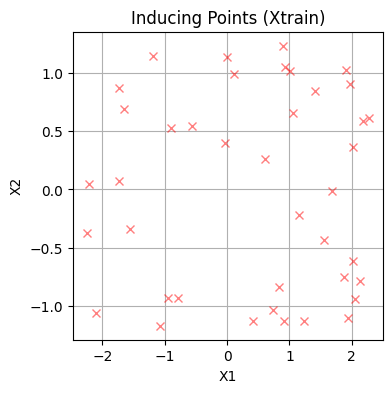

In [6]:
# Plot the Xtrain points in 2D space
if Xtrain.shape[0] >= 2:    # Optional Plotting in 2D space
    Xtrain_plot = Xtrain.cpu()
    plt.figure(figsize=(4,4))
    for i in range(Xtrain.shape[1]):
        plt.plot(Xtrain_plot[0,i], Xtrain_plot[1,i], linestyle='None', marker='x', color='red', alpha=0.5)
    plt.xlabel('X1'), plt.ylabel('X2'), plt.grid()
    plt.title('Inducing Points (Xtrain)')
    plt.show()

#### Verify Cost Function Works

In [7]:
# t_start = time.perf_counter()
# cost1 = get_cost_ACnew(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=1.0, lambda2=0., lambda3=1.)   # compute cost
# t_cost1 = time.perf_counter() - t_start

# t_start = time.perf_counter()
# cost2 = get_cost_ACnew2(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=1.0, lambda2=0., lambda3=0.)   # compute cost
# t_cost2 = time.perf_counter() - t_start

# # print(f'Initial Cost-1 [Vectorizd NLPD] is {cost1.cpu().detach()} in {t_cost1} seconds')
# print(f'Initial Cost-1 [Batched Multi-variate NLPD] is {cost2.cpu().detach()} in {t_cost2} seconds')

### Main Optimization Loop

In [ ]:
# Optimization Parameters: Maximum Iterations | Learning Rate | Target Error
max_iter, learn_rate, err_thresh = 2500, 0.0025, 0.1

lambda1, lambda2, lambda3 = 10., 1., 10.
# No-Improvement stopping criterion: Iters to monitor | Min decrease in cost
patience, min_delta = 10, 5e-1

print('Starting Iteration Loop!')
cost_history, iter, count_insignificant = [], 0, 0

# Optimization Options: "Spaced HPOpt" | "Opt all" | "Z only"
routine_name = "SpacedOpt"

if routine_name == "Opt all":
    # Gather parameters from each observable in the manager.
    all_hp1, all_hp2, all_noise, all_mu = [], [], [], []
    for obs in ObsManager.observables.values():
        all_hp1.extend(list(obs.hp1_list))
        all_hp2.extend(list(obs.hp2_list))
        all_noise.append(obs.noise)
        all_mu.extend(list(obs.mu_list))
    
    optimizer = torch.optim.Adam([Z] + all_hp1 + all_hp2, lr=learn_rate)
    # optimizer = torch.optim.SGD([Z] + all_hp1 + all_hp2, lr=learn_rate, momentum=0.9, nesterov=True)
    # softplus on Kernel parameters is handled inside GPO forward call - modify the package to toggle that option
    while iter < max_iter:
        # Reset gradients to zero
        optimizer.zero_grad()
        
        cost = get_cost_ACnew2(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3)   # compute cost
        cost_history.append(cost.item())    # add to cost history
        cost.backward(retain_graph=False)    # backpropagate

        optimizer.step()    # gradient descent step

        print(f"Iteration {iter}/{max_iter} with {count_insignificant} Insignificant Iterations")
        print(f"Cost: {cost.item()}")

        ObsManager.print_parameters()

        # Stopping conditions
        # if cost.item() < err_thresh:
        #     print("Stopping: Error threshold reached.")
        #     break
        # Increment iteration
        iter += 1

elif routine_name == 'SpacedOpt':
    # ---- configuration ----
    phase_len_hp      = 200    # steps of HP optimization per phase
    phase_len_z       = 100    # steps of Z optimization per phase
    reserve_final_z   = 600   # last iterations dedicated to Z-only

    # ---- collect hyperparameters from the manager ----
    hp_params = []
    for obs in ObsManager.observables.values():
        hp_params += list(getattr(obs, "hp1_list", []))
        hp_params += list(getattr(obs, "hp2_list", []))
        # noise = getattr(obs, "noise", None)
        # if isinstance(noise, torch.nn.Parameter):
        #     hp_params.append(noise)

    # ---- two optimizers ----
    lr_Z  = learn_rate
    lr_HP = learn_rate * 0.5  # a bit smaller for HPs is often more stable
    optZ  = torch.optim.Adam([Z],        lr=lr_Z)
    optHP = torch.optim.Adam(hp_params,  lr=lr_HP) if hp_params else None

    def set_requires(params, flag: bool):
        for p in params:
            if p is not None:
                p.requires_grad_(flag)

    iter = 0
    cost_history = []

    # We will alternate HP -> Z until 'switch_point', then Z-only for the last 200 iters.
    switch_point = max(0, max_iter - reserve_final_z)

    # ---------- Alternating phases (HP first) ----------
    while iter < switch_point:
        # ---- Phase: HP ----
        if optHP and phase_len_hp > 0:
            set_requires([Z], False)
            set_requires(hp_params, True)
            steps = min(phase_len_hp, switch_point - iter)
            for _ in range(steps):
                optHP.zero_grad(set_to_none=True)
                cost = get_cost_ACnew2(
                    Z, X, Xplus, Xtrain, ObsManager,
                    nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3
                )
                cost.backward()
                # optional: torch.nn.utils.clip_grad_norm_(hp_params, max_norm=1.0)
                optHP.step()
                cost_history.append(cost.item())
                iter += 1
                print(f"[{iter}/{max_iter}] Phase=HP | Cost={cost.item():.6e}")
                if iter >= switch_point: break

        if iter >= switch_point: break

        # ---- Phase: Z ----
        if phase_len_z > 0:
            set_requires([Z], True)
            set_requires(hp_params, False)
            steps = min(phase_len_z, switch_point - iter)
            for _ in range(steps):
                optZ.zero_grad(set_to_none=True)
                cost = get_cost_ACnew2(
                    Z, X, Xplus, Xtrain, ObsManager,
                    nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3
                )
                cost.backward()
                # optional: torch.nn.utils.clip_grad_norm_([Z], max_norm=5.0)
                optZ.step()
                cost_history.append(cost.item())
                iter += 1
                print(f"[{iter}/{max_iter}] Phase=Z | Cost={cost.item():.6e}")
                if iter >= switch_point: break

    # ---------- Final Z-only phase (last 200 iters) ----------
    set_requires([Z], True)
    set_requires(hp_params, False)
    while iter < max_iter:
        optZ.zero_grad(set_to_none=True)
        cost = get_cost_ACnew2(
            Z, X, Xplus, Xtrain, ObsManager,
            nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3
        )
        cost.backward()
        # optional: torch.nn.utils.clip_grad_norm_([Z], max_norm=5.0)
        optZ.step()
        cost_history.append(cost.item())
        iter += 1
        print(f"[{iter}/{max_iter}] Phase=Z(final) | Cost={cost.item():.6e}")

elif routine_name == "Z only":
    # Adam - Non-Stochastic | Faster Convergence, lesser exploration
    # optimizer = torch.optim.Adam([Z], lr=learn_rate)
    # SGD - lr in range 1e-3 | More Exploration.
    optimizer = torch.optim.SGD([Z], lr=learn_rate, momentum=0.75, nesterov=True)
    while iter < max_iter:
        optimizer.zero_grad()  # Clear gradients
        cost = get_cost_ACnew2(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3)   # compute cost
        cost_history.append(cost.item())    # add to cost history
        cost.backward()    # backpropagate
        optimizer.step()    # gradient descent step
        print(f"Iteration {iter + 1}/{max_iter}")
        print(f"Cost: {cost.item()}")
        # Stopping conditions
        # if cost.item() < err_thresh:
        #     print("Stopping: Error threshold reached.")
        #     break
        # Increment iteration
        iter += 1

elif routine_name == "Z and hp-opt":
    # Gather parameters from each observable in the manager.
    all_hp1, all_hp2, all_noise = [], [], []
    for obs in ObsManager.observables.values():
        all_hp1.extend(list(obs.hp1_list))
        all_hp2.extend(list(obs.hp2_list))
        # all_noise.append(obs.noise)
    
    # optimizer = torch.optim.Adam([Z] + all_hp1 + all_hp2, lr=learn_rate)
    optimizer = torch.optim.SGD([Z] + all_hp1 + all_hp2, lr=learn_rate, momentum=0.9, nesterov=True)
    while iter < max_iter:
        # Reset gradients to zero
        optimizer.zero_grad()
        
        cost = get_cost_ACnew2(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3)   # compute cost
        # cost = get_cost_varsep(Z, X, Xplus, ObsManager, nTrain)
        cost_history.append(cost.item())    # add to cost history
        cost.backward(retain_graph=False)    # backpropagate
        for i, theta in enumerate(all_hp1): # clip hp1 gradients
            if theta.grad is not None:
                theta.grad.data = torch.nan_to_num(theta.grad.data)
                theta.grad.data = torch.clamp(theta.grad.data, min=-1e1, max=1e1)
                print(f"hp1 parameter {i} grad: {theta.grad}")
                
            else:
                print(f"hp1 parameter {i} has no gradient.")
        
        print("Gradients for hp2:")
        for i, theta in enumerate(all_hp2): # clip hp2 gradients
            if theta.grad is not None:
                theta.grad.data = torch.nan_to_num(theta.grad.data)
                theta.grad.data = torch.clamp(theta.grad.data, min=-1e1, max=1e1)
                print(f"hp2 parameter {i} grad: {theta.grad}")

            else:
                print(f"hp2 parameter {i} has no gradient.")

        optimizer.step()    # gradient descent step

        print(f"Iteration {iter}/{max_iter} with {count_insignificant} Insignificant Iterations")
        print(f"Cost: {cost.item()}")

        ObsManager.print_parameters()
        iter += 1

else:
    raise ValueError('Invalid routine_name')

if iter == max_iter:    # Print Stopping Criterion
    print(f'Stopping: Reached maximum number of iterations = {iter}.')

optimal_Z = Z.detach()
print('Optimization Complete.')
print("Final Cost:", cost.item())

### View Optimization Logs

In [ ]:
# Plot cost history
plt.figure(figsize=(6,4))
plt.plot(cost_history, label="Cost")
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend(), plt.grid()
plt.show()

# Logarithmic cost history
plt.figure(figsize=(6,4))
plt.plot(torch.log10(torch.abs(torch.tensor(cost_history))), label="log(Cost)")
plt.title("Logarithmic Cost History")
plt.xlabel("Iteration")
plt.ylabel("log10(Cost)")
plt.legend(), plt.grid()
plt.show()

In [ ]:
ObsManager.print_parameters()

### Post-Process Optimization Results

In [ ]:
# Use Optimal Z values to Build GP Models and Optimal A and Z matrices
optimal_Z = Z.detach()
for i in range(p):
    ObsManager.train_observable(i, Xtrain, optimal_Z[:,i])  # train GP Observables with Optimal Z outputs

ObsManager.optimize_hyperparameters(opt_mu=False, opt_sigma=True, max_iter=20)   # Optimize Kernel hyperparameters for Optimal training data
# print(f'GPO Hyperparameters have been optimized.')
ObsManager.print_parameters()

ObsList = [i for i in range(p)]
A, C = gpk.getKoopman(ObsManager, ObsList, Xall, nTrain, stateAug=False)

# Simulation and Validation

## Model Simulation

In [ ]:
A, C = A.to(device='cpu'), C.to(device='cpu')
SimData = SimData.to(device='cpu')
ICsetTrain, ICsetTest = ICsetTrain.to(device='cpu'), ICsetTest.to(device='cpu')

# Evaluation on training set
ZmeanTrain = torch.empty((nTrain, p, N))
ZcvTrain   = torch.empty((nTrain, p, p, N))
XhatTrain  = torch.empty((nTrain, n, N))
XcvhatTrain= torch.empty((nTrain, n, n, N))

# -- new: containers for normalized RMSE
TrainNRMSE = torch.empty((nTrain, n))

for j in range(nTrain):
    # predict initial lifted states
    for i in range(p):
        ZmeanTrain[j, i, 0]    = ObsManager.predict_mean(i, ICsetTrain[:, j].view(n,1))
        ZcvTrain  [j, i, i, 0] = ObsManager.predict_covariance(i, ICsetTrain[:, j].view(n,1))

    # simulate
    ZmeanTrain[j], ZcvTrain[j], XhatTrain[j], XcvhatTrain[j] = gpk.sim_LTI(
        ZmeanTrain[j,:,0], A, C, num_steps=N, ts=None, x0cv=ZcvTrain[j,:,:,0]
    )

    # absolute RMSE per state
    errors = XhatTrain[j] - SimData_clean[j, :, :N]               # (n, N)
    rmse   = torch.sqrt(torch.mean(errors**2, dim=1))       # (n,)

    # true‐value range per state
    true_vals  = SimData[j, :, :N]                          # (n, N)
    max_vals   = true_vals.max(dim=1).values                # (n,)
    min_vals   = true_vals.min(dim=1).values                # (n,)
    range_vals = max_vals - min_vals                        # (n,)

    # avoid division by zero
    range_vals = torch.where(range_vals == 0,
                             torch.ones_like(range_vals),
                             range_vals)

    # normalized RMSE
    TrainNRMSE[j] = rmse / range_vals

# Evaluation on test set
ZmeanTest  = torch.empty((nTest, p, N))
ZcvTest    = torch.empty((nTest, p, p, N))
XhatTest   = torch.empty((nTest, n, N))
XcvhatTest = torch.empty((nTest, n, n, N))

# -- new: container for test normalized RMSE
TestNRMSE = torch.empty((nTest, n))

for j in range(nTest):
    for i in range(p):
        ZmeanTest[j, i, 0]    = ObsManager.predict_mean(i, ICsetTest[:, j].view(n,1))
        ZcvTest   [j, i, i, 0] = ObsManager.predict_covariance(i, ICsetTest[:, j].view(n,1))

    ZmeanTest[j], ZcvTest[j], XhatTest[j], XcvhatTest[j] = gpk.sim_LTI(
        ZmeanTest[j,:,0], A, C, num_steps=N, ts=None, x0cv=ZcvTest[j,:,:,0]
    )

    errors = XhatTest[j] - SimData_clean[nTrain + j, :, :N]     # make sure to index test trajectories correctly
    rmse   = torch.sqrt(torch.mean(errors**2, dim=1))

    true_vals  = SimData[nTrain + j, :, :N]
    max_vals   = true_vals.max(dim=1).values
    min_vals   = true_vals.min(dim=1).values
    range_vals = max_vals - min_vals
    range_vals = torch.where(range_vals == 0,
                             torch.ones_like(range_vals),
                             range_vals)

    TestNRMSE[j] = rmse / range_vals

# detach if you like
XhatTrain, XhatTest, XcvhatTrain, XcvhatTest = XhatTrain.detach(), XhatTest.detach(), XcvhatTrain.detach(), XcvhatTest.detach()
TrainRMSE, TestRMSE = TrainNRMSE.detach(), TestNRMSE.detach()

In [ ]:
time = torch.arange(0., ts * N, ts)
idx1, idx2, idx3 = torch.argmin(TrainRMSE.mean(dim=1)), torch.argmin(TestRMSE.mean(dim=1)), torch.argmax(TestRMSE.mean(dim=1))

## Trajectory and Time-Evolution Plots

In [ ]:
# # Move norm params to CPU to match plotting tensors
# mu_vec_cpu  = mu_vec.to('cpu')
# std_vec_cpu = std_vec.to('cpu')

# # Denormalize predictions (keep originals if you still want normalized metrics)
# XhatTrain_den   = denorm_states(XhatTrain.cpu(),  mu_vec_cpu, std_vec_cpu)
# XhatTest_den    = denorm_states(XhatTest.cpu(),   mu_vec_cpu, std_vec_cpu)
# XcvhatTrain_den = denorm_covariances(XcvhatTrain.cpu(), std_vec_cpu)
# XcvhatTest_den  = denorm_covariances(XcvhatTest.cpu(),  std_vec_cpu)

# # Example replacements for plotting calls
# gpk.plot_phase(XhatTrain_den, SimData_raw, ICsetTrain, idx1, N, system_name, 'Training Trajectory')
# gpk.plot_time_series_with_bounds(time, XhatTrain_den, XcvhatTrain_den, SimData_raw, idx1, N, system_name, title_suffix='Best Train Trajectory')

# gpk.plot_phase(XhatTest_den, SimData_raw, ICsetTest, idx2, N, system_name, 'Best Test Trajectory', sim_offset=nTrain)
# gpk.plot_time_series_with_bounds(time, XhatTest_den, XcvhatTest_den, SimData_raw, idx2, N, system_name, title_suffix='Best Test Trajectory', sim_offset=nTrain)

# # For plotting, use:
# # - Predictions: *_den (denormalized)
# # - Ground truth: SimData_raw (original physical units)
# gpk.plot_phase(XhatTrain_den, SimData_raw, ICsetTrain, idx1, N, system_name, 'Training Trajectory')
# gpk.plot_time_series_with_bounds(time, XhatTrain_den, XcvhatTrain_den, SimData_raw, idx1, N, system_name, title_suffix='Best Train Trajectory')

# gpk.plot_phase(XhatTest_den, SimData_raw, ICsetTest, idx2, N, system_name, 'Best Test Trajectory', sim_offset=nTrain)
# gpk.plot_time_series_with_bounds(time, XhatTest_den, XcvhatTest_den, SimData_raw, idx2, N, system_name, title_suffix='Best Test Trajectory', sim_offset=nTrain)

# gpk.plot_phase(XhatTest_den, SimData_raw, ICsetTest, idx3, N, system_name, 'Worst Test Trajectory', sim_offset=nTrain)
# gpk.plot_time_series_with_bounds(time, XhatTest_den, XcvhatTest_den, SimData_raw, idx3, N, system_name, title_suffix='Worst Test Trajectory', sim_offset=nTrain)

Best and Worst Trajectory Plots (Normalized)

In [ ]:
gpk.plot_phase(XhatTrain, SimData, ICsetTrain, idx1, N, system_name, 'Training Trajectory')
gpk.plot_time_series_with_bounds(time, XhatTrain, XcvhatTrain, SimData, idx1, N, system_name, title_suffix='Best Train Trajectory')

gpk.plot_phase(XhatTest, SimData, ICsetTest, idx2, N, system_name, 'Best Test Trajectory', sim_offset=nTrain)
gpk.plot_time_series_with_bounds(time, XhatTest, XcvhatTest, SimData, idx2, N, system_name, title_suffix='Best Test Trajectory', sim_offset=nTrain)

gpk.plot_phase(XhatTest, SimData, ICsetTest, idx3, N, system_name, 'Worst Test Trajectory', sim_offset=nTrain)
gpk.plot_time_series_with_bounds(time, XhatTest, XcvhatTest, SimData, idx3, N, system_name, title_suffix='Worst Test Trajectory', sim_offset=nTrain)

In [ ]:
# For best test trajectory (e.g., idx2)
gpk.plot_predicted_sd_error(XcvhatTest, SimData, XhatTest, idx=idx2, N=N, nTrain=nTrain, trajectory_label="Best Test")

# For worst test trajectory (e.g., idx3)
gpk.plot_predicted_sd_error(XcvhatTest, SimData, XhatTest, idx=idx3, N=N, nTrain=nTrain, trajectory_label="Worst Test")

## System-level Plots

### Normalized RMSE for Training and Test Sets

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Training set plot
axes[0].plot(range(nTrain), TrainRMSE[:,0].numpy(), marker='o', linestyle='-', label='NRMSE X1')
axes[0].plot(range(nTrain), TrainRMSE[:,1].numpy(), marker='o', linestyle='-', label='NRMSE X2')
axes[0].set_title('Training Metrics')
axes[0].set_xlabel("Trajectory Index")
axes[0].set_ylabel("Metric Value")
axes[0].legend()
axes[0].grid()

# Test set plot
axes[1].plot(range(nTest), TestRMSE[:,0].numpy(), marker='o', linestyle='-', label='NRMSE X1')
axes[1].plot(range(nTest), TestRMSE[:,1].numpy(), marker='o', linestyle='-', label='NRMSE X2')
axes[1].set_title('Test Metrics')
axes[1].set_xlabel("Trajectory Index")
axes[1].set_ylabel("Metric Value")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [ ]:
def plot_eigen(A):
    # Eigen value plot of Koopman Matrices
    eigval = torch.linalg.eigvals(A)

    eigreal, eigimag = eigval.real, eigval.imag
    eigreal, eigimag = eigreal.detach().numpy(), eigimag.detach().numpy()
    eig_mag = np.sqrt(eigreal**2 + eigimag**2)

    theta = np.linspace(0, 2*np.pi, 500)
    unitCirclex, unitCircley = np.cos(theta), np.sin(theta)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    # First subplot: Eigenvalues plot
    axes[0].plot(unitCirclex, unitCircley, color='orange', label='Unit Circle')
    for i in range(np.size(eig_mag)):
        if eig_mag[i] <= 1:
            axes[0].scatter(eigreal, eigimag, color='green', label='Eigenvalues')
        else:
            axes[0].scatter(eigreal, eigimag, color='red', label='Eigenvalues')

    axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
    axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')
    axes[0].set_title(f"Eigenvalues of A Matrix with {p} Observables")
    axes[0].set_xlabel("Real Part")
    axes[0].set_ylabel("Imaginary Part")
    axes[0].grid(True)
    axes[0].legend(labels=['Unit Circle', 'Eignevalues'], loc='upper right')

    # Second subplot: Heatmap of matrix A
    im = axes[1].imshow(A.detach().numpy(), cmap='viridis', aspect='auto')
    fig.colorbar(im, ax=axes[1], label="Value")
    axes[1].set_title(f'{A.shape[0]}-D Koopman Matrix')
    axes[1].set_xlabel("Columns")
    axes[1].set_ylabel("Rows")
    plt.tight_layout()
    plt.show()

plot_eigen(A)

### All Trajectories: Original and Model

In [ ]:
# Phase Diagram from all IC simulation
if SimData.shape[1] == 3:       # 3D plot
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    for j in range(SimData.shape[0]):
        ax.plot(SimData[j, 0, :], SimData[j, 1, :], SimData[j, 2, :],
                alpha=0.5, color='blue')
        ax.scatter(SimData[j, 0, 0], SimData[j, 1, 0], SimData[j, 2, 0],
                   color='red')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title(f'All Trajectories: {system_name}')
    ax.grid(True)
    plt.show()

elif SimData.shape[1] == 2:     # 2D plot
    for j in range(SimData.shape[0]):
        plt.plot(SimData[j, 0, :], SimData[j, 1, :],
                 alpha=0.5, color='blue', linewidth=1.)
        plt.plot(SimData[j, 0, 0], SimData[j, 1, 0],
                 'o', color='red')
    plt.grid()
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(f'All Trajectories: {system_name}')
    plt.show()

elif SimData.shape[1] == 1:     # 1D plot
    for j in range(SimData.shape[0]):
        plt.plot(SimData[j, 0, :], alpha=0.5, color='blue', linewidth=1.)
        plt.plot(SimData[j, 0, 0], 'o', color='red')
    plt.grid()
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(f'All Trajectories: {system_name}')
    plt.show()

else:   # system dimension > 3
    print('IC Phase Plots supported for 1/2/3-D systems only.')


# Training Set Predicted Trajectories
if XhatTrain.shape[1] == 3: # 3D plot
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    for j in range(XhatTrain.shape[0]):
        ax.plot(XhatTrain[j, 0, :], XhatTrain[j, 1, :], XhatTrain[j, 2, :],
                alpha=0.5, color='blue')
        ax.scatter(XhatTrain[j, 0, 0], XhatTrain[j, 1, 0], XhatTrain[j, 2, 0],
                   color='red')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title(f'Predicted Trajectories - Training Set: {system_name}')
    ax.grid(True)
    plt.show()

elif XhatTrain.shape[1] == 2:   # 2D plot
    for j in range(XhatTrain.shape[0]):
        plt.plot(XhatTrain[j, 0, :], XhatTrain[j, 1, :],
                 alpha=0.5, color='blue', linewidth=1.)
        plt.plot(XhatTrain[j, 0, 0], XhatTrain[j, 1, 0],
                 'o', color='red')
    plt.grid()
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(f'Predicted Trajectories - Training Set: {system_name}')
    plt.show()

else:
    print('Trianing Response Phase PLots supported for 2/3-D systems only.')

# Model Saving

In [ ]:
today = datetime.date.today()

iGPKResults = {
    "Sysem Name": system_name,
    "Data": SimData,
    "Train Test Factors": [nTrain, nTest],
    "Initial Conditions": [ICsetTrain, ICsetTest],
    "ObsManager": ObsManager,
    "Observables": ObsManager.observables,
    "Koopman A": A,
    "Koopman C": C,
    "X Train": Xtrain,
    "Optimal Z": optimal_Z,
    "Train RMSE": TrainRMSE,
    "Test RMSE": TestRMSE,
    "Adam Options": [learn_rate, max_iter, lambda1, lambda2, lambda3]
}

# torch.save(iGPKResults, f'Results/iGPKAuto_{system_name}_Noisy_{today}.pt')